<a id="import"></a>
# <center>Import Need Modules</center>

In [1]:
# ======================
# Google Colab environment
# ======================
from google.colab import drive

# ======================
# Core libraries
# ======================
import os
import time
import shutil
import numpy as np
import pandas as pd

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ======================
# Visualization
# ======================
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

sns.set_style('darkgrid')

# ======================
# Machine Learning utilities
# ======================
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ======================
# TensorFlow & Keras
# ======================
import tensorflow as tf
from tensorflow import keras

# Mixed precision (float32 is default — but ok)
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('float32')
mixed_precision.set_global_policy(policy)

print('Compute dtype:', policy.compute_dtype)
print('Variable dtype:', policy.variable_dtype)

# Keras layers, models, utilities
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Dense, Activation, Dropout, Conv2D, MaxPooling2D,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)

# ======================
# GPU Check
# ======================
print("GPU Available:", tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    print("GPU detected! Training will be fast.")
else:
    print("No GPU detected. Training will be slow.")

Compute dtype: float32
Variable dtype: float32
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU detected! Training will be fast.


In [2]:
# Install Albumentations (run once in the notebook environment)
# If running locally, you can comment out the pip install line and install via your environment
%pip install albumentations==1.1.0 -q

import albumentations as A
import numpy as np

# Define richer training augmentations to better simulate real-world clutter
train_augment = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.08, rotate_limit=20, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.GridDropout(ratio=0.2, p=0.3),
    A.CoarseDropout(max_holes=1, max_height=50, max_width=50, p=0.3),
], p=1.0)

# Preprocessing function for ImageDataGenerator: apply Albumentations then EfficientNet preprocess
def albumentations_preprocess(image):
    # ImageDataGenerator passes images as float32 arrays in [0,255]
    img_uint8 = image.astype('uint8')
    augmented = train_augment(image=img_uint8)['image']
    # Convert to float32 and apply EfficientNet preprocessing
    return tf.keras.applications.efficientnet.preprocess_input(augmented.astype('float32'))



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.4/102.4 kB 6.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/transforms.py:1952: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  warnings.warn(


### The size of the images are very large. If you try to use the full image size training will take a very long time. Therefore you
### want to reduce the image size. However if you include resizing of images as part of training it requires each image to be repeatedly
### resized in each epoch. This also make the training times to be large. It is more efficient to resize all the images FIRST and save them.
### Then use these images for training.

<a id="resize"></a>
# <center>Resize all images and save to the working directory</center>

In [3]:
# Mount Google Drive
drive.mount('/content/drive')
start_time=time.time()
sdir = '/content/drive/MyDrive/dataset_train'
working_dir = '/content/cauliflower_training/'
img_height = 300
img_width = 300

# Create working directory first
os.makedirs(working_dir, exist_ok=True)

save_path = os.path.join(working_dir, 'cali')

if os.path.isdir(save_path):
    shutil.rmtree(save_path) # if the directory exists remove it

os.makedirs(save_path, exist_ok=True)  # Changed from os.mkdir() to os.makedirs()

classlist = sorted(os.listdir(sdir))
for klass in classlist:
    classpath = os.path.join(sdir, klass)
    if not os.path.isdir(classpath):  # skip if not a directory
        continue
    print('processing ', klass,  ' class')
    class_dest_path = os.path.join(save_path, klass)
    os.makedirs(class_dest_path, exist_ok=True)  # Changed here too
    flist = os.listdir(classpath)
    for f in flist:
        fpath = os.path.join(classpath,f)
        f_dest_path = os.path.join(class_dest_path, f)
        try: # make sure images are correct image files
            # Use PIL to ensure consistent RGB handling across readers
            with Image.open(fpath) as img:
                img = img.convert('RGB')
                # Use modern resampling API when available
                try:
                    resample_method = Image.Resampling.LANCZOS
                except AttributeError:
                    resample_method = Image.LANCZOS if hasattr(Image, 'LANCZOS') else Image.NEAREST
                img = img.resize((img_height, img_width), resample_method)
                img.save(f_dest_path)
        except Exception as e:
            print('Image ', fpath, ' is an invalid image file:', e)

tr_duration = time.time() - start_time
hours = tr_duration // 3600
minutes = (tr_duration - (hours * 3600)) // 60
seconds = tr_duration - ((hours * 3600) + (minutes * 60))
msg = f'resizing elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
print(msg, flush=True)

Mounted at /content/drive
processing  Alternaria Leaf Spot  class
processing  Bacterial Soft Rot  class
processing  Black Rot  class
processing  Downy Mildew  class
processing  Healthy  class
resizing elapsed time was 0.0 hours,  9.0 minutes, 19.25 seconds)


In [4]:
sdir = '/content/drive/MyDrive/dataset_train'
quarantine = os.path.join(working_dir, 'quarantine')
os.makedirs(quarantine, exist_ok=True)

moved = 0
for root, _, files in os.walk(sdir):
    for f in files:
        path = os.path.join(root, f)
        # skip if already in quarantine
        try:
            if os.path.commonpath([quarantine, path]) == quarantine:
                continue
        except ValueError:
            # fallback when commonpath can't compare (different path types/drives)
            abs_quarantine = os.path.abspath(quarantine)
            abs_path = os.path.abspath(path)
            if abs_path == abs_quarantine or abs_path.startswith(abs_quarantine + os.sep):
                continue
        try:
            with Image.open(path) as im:
                im.verify()  # will raise if file is truncated or not an image
        except Exception:
            rel = os.path.relpath(path, sdir)
            dest_path = os.path.join(quarantine, rel)
            os.makedirs(os.path.dirname(dest_path), exist_ok=True)
            try:
                shutil.move(path, dest_path)
                moved += 1
            except Exception as e:
                print('Failed to move', path, '->', dest_path, ':', e)

print(f'Moved {moved} files to quarantine: {quarantine}')

Moved 0 files to quarantine: /content/cauliflower_training/quarantine


<a id="makedf"></a>
# <center>Read in resized images and create a dataframe of image paths and class labels</center>

In [5]:
def make_df(save_path):
    classlist=os.listdir(save_path)
    filepaths=[]
    labels=[]
    for klass in classlist:
        classpath=os.path.join(save_path, klass)
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            filepaths.append(fpath)
            labels.append(klass)
    Fseries=pd.Series(filepaths, name='filepaths')
    Lseries=pd.Series(labels, name='labels')
    df=pd.concat([Fseries, Lseries], axis=1)
    train_df, dummy_df=train_test_split(df, train_size=.8, shuffle=True, random_state=123, stratify=df['labels'])
    valid_df, test_df=train_test_split(dummy_df,train_size=.5, shuffle=True, random_state=123, stratify=dummy_df['labels'])
    print('train_df lenght: ', len(train_df), '  test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))
    # get the number of classes and the images count for each class in train_df
    classes=sorted(list(train_df['labels'].unique()))
    class_count = len(classes)
    print('The number of classes in the dataset is: ', class_count)
    groups=train_df.groupby('labels')
    print('{0:^30s} {1:^13s}'.format('CLASS', 'IMAGE COUNT'))
    countlist=[]
    classlist=[]
    for label in sorted(list(train_df['labels'].unique())):
        group=groups.get_group(label)
        countlist.append(len(group))
        classlist.append(label)
        print('{0:^30s} {1:^13s}'.format(label, str(len(group))))

    # get the classes with the minimum and maximum number of train images
    max_value=np.max(countlist)
    max_index=countlist.index(max_value)
    max_class=classlist[max_index]
    min_value=np.min(countlist)
    min_index=countlist.index(min_value)
    min_class=classlist[min_index]
    print(max_class, ' has the most images= ',max_value, ' ', min_class, ' has the least images= ', min_value)
    # lets get the average height and width of a sample of the train images
    ht=0
    wt=0
    # select 100 random samples of train_df
    train_df_sample=train_df.sample(n=100, random_state=123,axis=0)
    for i in range (len(train_df_sample)):
        fpath=train_df_sample['filepaths'].iloc[i]
        img=plt.imread(fpath)
        shape=img.shape
        ht += shape[0]
        wt += shape[1]
    print('average height= ', ht//100, ' average width= ', wt//100, 'aspect ratio= ', ht/wt)
    return train_df, test_df, valid_df, classes
train_df, test_df, valid_df, classes = make_df(save_path)
class_count=len(classes)

train_df lenght:  6203   test_df length:  776   valid_df length:  775
The number of classes in the dataset is:  5
            CLASS               IMAGE COUNT 
     Alternaria Leaf Spot          1206     
      Bacterial Soft Rot           1121     
          Black Rot                 627     
         Downy Mildew               721     
           Healthy                 2528     
Healthy  has the most images=  2528   Black Rot  has the least images=  627
average height=  300  average width=  300 aspect ratio=  1.0


<a id="balancing_dataset"></a>
# <center>Balancing Dataset</center>

In [6]:
# IMPROVED BALANCE FUNCTION - Now handles both upsampling AND downsampling
def balance(df, n, working_dir, img_size):
    """
    Balance dataset to exactly n samples per class by:
    1. Downsampling majority classes to n
    2. Augmenting minority classes up to n
    """
    df = df.copy()
    print(f'Initial dataframe length: {len(df)}')
    print('\n=== Initial Class Distribution ===')
    initial_dist = df['labels'].value_counts().sort_index()
    print(initial_dist)

    # STEP 1: DOWNSAMPLE majority classes first
    print(f'\n=== Step 1: Downsampling classes with > {n} samples ===')
    balanced_frames = []
    for label in sorted(df['labels'].unique()):
        class_df = df[df['labels'] == label]
        count = len(class_df)

        if count > n:
            class_df = class_df.sample(n=n, random_state=123)
            print(f'✓ Downsampled {label:30s} from {count:4d} to {n}')
        else:
            print(f'  Kept {label:30s} at {count:4d} samples (will augment later)')

        balanced_frames.append(class_df)

    df = pd.concat(balanced_frames, axis=0).reset_index(drop=True)
    print(f'\nAfter downsampling: {len(df)} total samples')

    # STEP 2: AUGMENT minority classes
    print(f'\n=== Step 2: Augmenting classes with < {n} samples ===')
    aug_dir = os.path.join(working_dir, 'aug')
    if os.path.isdir(aug_dir):
        shutil.rmtree(aug_dir)
    os.mkdir(aug_dir)

    for label in df['labels'].unique():
        dir_path = os.path.join(aug_dir, label)
        os.mkdir(dir_path)

    total_augmented = 0
    gen = ImageDataGenerator(
        horizontal_flip=True,
        rotation_range=20,
        width_shift_range=.2,
        height_shift_range=.2,
        zoom_range=.2
    )

    groups = df.groupby('labels')
    for label in sorted(df['labels'].unique()):
        group = groups.get_group(label)
        sample_count = len(group)

        if sample_count < n:
            delta = n - sample_count
            target_dir = os.path.join(aug_dir, label)
            print(f'✓ Creating {delta:3d} augmented images for {label:30s}')

            aug_gen = gen.flow_from_dataframe(
                group,
                x_col='filepaths',
                y_col=None,
                target_size=img_size,
                class_mode=None,
                batch_size=1,
                shuffle=False,
                save_to_dir=target_dir,
                save_prefix='aug-',
                color_mode='rgb',
                save_format='jpg'
            )

            aug_img_count = 0
            while aug_img_count < delta:
                images = next(aug_gen)
                aug_img_count += len(images)

            total_augmented += aug_img_count

    print(f'\nTotal augmented images created: {total_augmented}')

    # STEP 3: Merge augmented images
    aug_fpaths = []
    aug_labels = []
    classlist = os.listdir(aug_dir)
    for klass in classlist:
        classpath = os.path.join(aug_dir, klass)
        flist = os.listdir(classpath)
        for f in flist:
            fpath = os.path.join(classpath, f)
            aug_fpaths.append(fpath)
            aug_labels.append(klass)

    if aug_fpaths:
        Fseries = pd.Series(aug_fpaths, name='filepaths')
        Lseries = pd.Series(aug_labels, name='labels')
        aug_df = pd.concat([Fseries, Lseries], axis=1)
        df = pd.concat([df, aug_df], axis=0).reset_index(drop=True)

    print(f'\n=== Final Balanced Distribution ===')
    final_dist = df['labels'].value_counts().sort_index()
    print(final_dist)
    print(f'\nFinal dataframe length: {len(df)}')

    # Verify perfect balance
    if final_dist.nunique() == 1 and final_dist.iloc[0] == n:
        print(f'✓ SUCCESS: All classes perfectly balanced at {n} samples!')
    else:
        print('⚠ WARNING: Classes not perfectly balanced!')

    # Save to CSV
    try:
        merged_csv = os.path.join(working_dir, 'train_balanced.csv')
        df.to_csv(merged_csv, index=False)
        print(f'\n✓ Saved balanced dataset to: {merged_csv}')
    except Exception as e:
        print(f'Warning: could not save CSV: {e}')

    return df

# Apply balancing
n = 600  # Increased from 200 for better model training
working_dir = r'./'
img_size = (300, 300)

print('=' * 80)
print('BALANCING TRAINING DATASET')
print('=' * 80)
train_df = balance(train_df, n, working_dir, img_size)

BALANCING TRAINING DATASET
Initial dataframe length: 6203

=== Initial Class Distribution ===
labels
Alternaria Leaf Spot    1206
Bacterial Soft Rot      1121
Black Rot                627
Downy Mildew             721
Healthy                 2528
Name: count, dtype: int64

=== Step 1: Downsampling classes with > 600 samples ===
✓ Downsampled Alternaria Leaf Spot           from 1206 to 600
✓ Downsampled Bacterial Soft Rot             from 1121 to 600
✓ Downsampled Black Rot                      from  627 to 600
✓ Downsampled Downy Mildew                   from  721 to 600
✓ Downsampled Healthy                        from 2528 to 600

After downsampling: 3000 total samples

=== Step 2: Augmenting classes with < 600 samples ===

Total augmented images created: 0

=== Final Balanced Distribution ===
labels
Alternaria Leaf Spot    600
Bacterial Soft Rot      600
Black Rot               600
Downy Mildew            600
Healthy                 600
Name: count, dtype: int64

Final dataframe leng


<a id="rebuildcleanedcsv"></a>
# <center>Rebuild cleaned CSVs</center>

In [7]:
def write_clean_csv(input_csv, out_csv, quarantine_dir):
    df = pd.read_csv(input_csv)
    # drop any rows whose files were moved to quarantine
    if os.path.isdir(quarantine_dir):
        quarantined = set(os.listdir(quarantine_dir))
        df = df[~df['filepaths'].apply(lambda p: os.path.basename(p) in quarantined)].reset_index(drop=True)
    df.to_csv(out_csv, index=False)
    print('Wrote cleaned CSV:', out_csv)

# Define quarantine_dir (needed if you ran the repair cell earlier)
quarantine_dir = os.path.join(working_dir, 'quarantine')

# Only run if the input CSV exists
input_csv = os.path.join(working_dir, 'train_augmented.csv')
output_csv = os.path.join(working_dir, 'train_augmented_clean.csv')

if os.path.exists(input_csv):
    write_clean_csv(input_csv, output_csv, quarantine_dir)
else:
    print(f'Skipping CSV cleaning - {input_csv} not found yet (run balance function first)')

Skipping CSV cleaning - ./train_augmented.csv not found yet (run balance function first)


<a id="balance"></a>
# <center>Expand train_df by creating augmented images</center>


In [8]:
# Load the balanced dataset (skip if already balanced in memory)
balanced_csv = os.path.join(working_dir, 'train_balanced.csv')

if os.path.exists(balanced_csv):
    print(f"Loading pre-balanced dataset: {balanced_csv}")
    train_df = pd.read_csv(balanced_csv)
    if 'filepaths' not in train_df.columns:
        cols = list(train_df.columns)
        if len(cols) >= 2:
            train_df = train_df.rename(columns={cols[0]: 'filepaths', cols[1]: 'labels'})
    train_df = train_df[['filepaths', 'labels']]

    print(f'\n✓ Loaded balanced dataset: {len(train_df)} samples')
    print('\nClass distribution:')
    print(train_df['labels'].value_counts().sort_index())
else:
    print(f"⚠ {balanced_csv} not found — ensure you ran the balance() function first")

Loading pre-balanced dataset: ./train_balanced.csv

✓ Loaded balanced dataset: 3000 samples

Class distribution:
labels
Alternaria Leaf Spot    600
Bacterial Soft Rot      600
Black Rot               600
Downy Mildew            600
Healthy                 600
Name: count, dtype: int64


<a id="generators"></a>
# <center>Create the train_gen, test_gen final_test_gen and valid_gen</center>

In [9]:
batch_size = 128  # Reduced from 80 for better gradient updates with balanced data
AUTOTUNE = tf.data.AUTOTUNE

train_steps = int(np.ceil(len(train_df) / batch_size))
valid_steps = int(np.ceil(len(valid_df) / batch_size))
test_steps = int(np.ceil(len(test_df) / batch_size))

print(f'\n✓ tf.data datasets created successfully')
print(f'  Train steps (batches): {train_steps}')
print(f'  Valid steps (batches): {valid_steps}')
print(f'  Test steps (batches): {test_steps}')
print(f'  Number of classes: {class_count}')


✓ tf.data datasets created successfully
  Train steps (batches): 24
  Valid steps (batches): 7
  Test steps (batches): 7
  Number of classes: 5


<a id="show"></a>
# <center>Create a function to show example training images</center>

In [10]:
def show_image_samples_from_df(df, n=25):
    samp = df.sample(n=min(n, len(df)), random_state=123)
    plt.figure(figsize=(20, 20))
    for i, (_, row) in enumerate(samp.iterrows()):
        plt.subplot(5, 5, i + 1)
        img = Image.open(row['filepaths']).convert('RGB')
        img = img.resize((img_size[1], img_size[0]))
        plt.imshow(np.array(img) / 255.0)
        plt.title(row['labels'], color='blue', fontsize=14)
        plt.axis('off')
    plt.show()

show_image_samples_from_df(train_df)

Output hidden; open in https://colab.research.google.com to view.

<a id="model"></a>
# <center>Create a model using transfer learning with EfficientNetB3</center>
### NOTE experts advise you make the base model initially not trainable. Then train for some number of epochs
### then fine tune model by making base model trainable and run more epochs
### I have found this to be WRONG!!!!
### Making the base model trainable from the outset leads to faster convegence and a lower validation loss
### for the same number of total epochs!

In [11]:
img_shape = (img_size[0], img_size[1], 3)
model_name = 'EfficientNetB3'

print(f'Building {model_name} model...')

# Create base model
base_model = tf.keras.applications.efficientnet.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

base_model.trainable = True

# Build model with MODERATE regularization
x = base_model.output
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)

# Add intermediate layer for better feature learning
x = Dense(512, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(rate=.45, seed=123)(x)

x = Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(rate=.35, seed=123)(x)

# Output layer MUST be float32 for mixed precision
output = Dense(class_count, activation='softmax', dtype='float32', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model with lower initial learning rate
lr = 0.0005  # Reduced from 0.001 for more stable training
model.compile(
    Adamax(learning_rate=lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'\n✓ Model compiled with learning rate: {lr}')
print(f'  Total parameters: {model.count_params():,}')
model.summary()

Building EfficientNetB3 model...
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

✓ Model compiled with learning rate: 0.0005
  Total parameters: 11,709,236


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,709,236 (44.67 MB)

 Trainable params: 11,618,861 (44.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

<a id="callbacks"></a>
# <center>Instantiate custom callback

In [12]:
os.makedirs(quarantine_dir, exist_ok=True)
# Build class mapping
class_names = sorted(train_df['labels'].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
class_count = len(class_names)

# Helper to build tf.data datasets from dataframe
def df_to_dataset(df, training=False):
    paths = df['filepaths'].astype(str).values
    labels = df['labels'].map(class_to_idx).values.astype('int32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=1000, seed=123)
        ds = ds.map(lambda p, l: tf.py_function(func=_decode_and_preprocess_train, inp=[p, l], Tout=(tf.float32, tf.float32)), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda p, l: tf.py_function(func=_decode_and_preprocess_eval, inp=[p, l], Tout=(tf.float32, tf.float32)), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

# Functions used by tf.py_function must accept and return numpy-compatible types
def _decode_and_preprocess_train(path, label):
    path = path.numpy().decode('utf-8')
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.uint8).numpy()
    # Albumentations preprocessing returns float32 preprocessed image
    img_pp = albumentations_preprocess(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe

def _decode_and_preprocess_train(path, label):
    p = path.numpy().decode('utf-8')
    try:
        with Image.open(p) as im:
            im = im.convert('RGB')
            im = im.resize((img_size[1], img_size[0]))
            img = np.array(im, dtype=np.uint8)
    except Exception as e:
        # Move problematic file to quarantine to avoid repeated failures
        try:
            dest = os.path.join(quarantine_dir, os.path.basename(p))
            shutil.move(p, dest)
            print('Quarantined bad file:', p)
        except Exception:
            pass
        img = np.zeros((img_size[0], img_size[1], 3), dtype=np.uint8)
    img_pp = albumentations_preprocess(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe


def _decode_and_preprocess_eval(path, label):
    p = path.numpy().decode('utf-8')
    try:
        with Image.open(p) as im:
            im = im.convert('RGB')
            im = im.resize((img_size[1], img_size[0]))
            img = np.array(im, dtype=np.float32)
    except Exception:
        img = np.zeros((img_size[0], img_size[1], 3), dtype=np.float32)
    img_pp = tf.keras.applications.efficientnet.preprocess_input(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe

In [13]:
def _py_train(path, label):
    img, lbl = tf.py_function(func=_decode_and_preprocess_train, inp=[path, label], Tout=(tf.float32, tf.float32))
    img.set_shape([img_size[0], img_size[1], 3])
    lbl.set_shape([class_count])
    return img, lbl


def _py_eval(path, label):
    img, lbl = tf.py_function(func=_decode_and_preprocess_eval, inp=[path, label], Tout=(tf.float32, tf.float32))
    img.set_shape([img_size[0], img_size[1], 3])
    lbl.set_shape([class_count])
    return img, lbl

# Rebuild TF datasets using the shape-aware wrappers defined earlier
print('Rebuilding tf.data datasets with robust PIL loaders...')
train_paths = train_df['filepaths'].astype(str).values
train_labels = train_df['labels'].map(class_to_idx).values.astype('int32')
valid_paths = valid_df['filepaths'].astype(str).values
valid_labels = valid_df['labels'].map(class_to_idx).values.astype('int32')
test_paths = test_df['filepaths'].astype(str).values
test_labels = test_df['labels'].map(class_to_idx).values.astype('int32')

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(buffer_size=1000, seed=123)
train_ds = train_ds.map(_py_train, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(AUTOTUNE)

valid_ds = tf.data.Dataset.from_tensor_slices((valid_paths, valid_labels))
valid_ds = valid_ds.map(_py_eval, num_parallel_calls=AUTOTUNE)
valid_ds = valid_ds.batch(batch_size).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(_py_eval, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(AUTOTUNE)

# Recompute steps
train_steps = int(np.ceil(len(train_df) / batch_size))
valid_steps = int(np.ceil(len(valid_df) / batch_size))
test_steps = int(np.ceil(len(test_df) / batch_size))

print(f'  Train steps (batches): {train_steps}')
print(f'  Valid steps (batches): {valid_steps}')
print(f'  Test steps (batches): {test_steps}')

Rebuilding tf.data datasets with robust PIL loaders...
  Train steps (batches): 24
  Valid steps (batches): 7
  Test steps (batches): 7


<a id="class_distribution"></a>
# <center>Check generator class distribution/center>

In [14]:
print('\n=== Dataset Class Distribution ===')
print('Train distribution:')
train_class_dist = train_df['labels'].value_counts().sort_index()
for class_name, count in train_class_dist.items():
    print(f'  {class_name:30s}: {count:4d} samples')

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(class_count),
    y=train_df['labels'].map(class_to_idx).values
)

class_weight_dict = dict(enumerate(class_weights))
print("\n=== Computed Class Weights ===")
for idx, class_name in enumerate(class_names):
    print(f"  {class_name:30s} -> Weight: {class_weight_dict[idx]:.4f}")

print("\n✓ Class weights will provide additional balancing during training")


=== Dataset Class Distribution ===
Train distribution:
  Alternaria Leaf Spot          :  600 samples
  Bacterial Soft Rot            :  600 samples
  Black Rot                     :  600 samples
  Downy Mildew                  :  600 samples
  Healthy                       :  600 samples

=== Computed Class Weights ===
  Alternaria Leaf Spot           -> Weight: 1.0000
  Bacterial Soft Rot             -> Weight: 1.0000
  Black Rot                      -> Weight: 1.0000
  Downy Mildew                   -> Weight: 1.0000
  Healthy                        -> Weight: 1.0000

✓ Class weights will provide additional balancing during training


In [15]:
epochs = 150  # Increased for better convergence

# Save best model to Google Drive
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_cauliflower_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by half
    patience=4,  # Wait 3 epochs before reducing
    min_lr=1e-7,
    verbose=1,
    mode='min'
)

# Stop early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,  # Increased patience for better training
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

callbacks = [checkpoint, reduce_lr, early_stop]
print('✓ Callbacks configured:')

✓ Callbacks configured:


<a id="train"></a>
# <center>Train the model
### Note unlike how you are told it is BETTER to make the base model trainable from the outset
### It will converge faster and have a lower validation losss

In [16]:
print('STARTING TRAINING')
print('=' * 80)
print(f'Epochs: {epochs}')
print(f'Batch size: {batch_size}')
print(f'Steps per epoch: {train_steps}')
print(f'Validation steps: {valid_steps}')
print('=' * 80)

history = model.fit(
    x=train_ds,
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_ds,
    steps_per_epoch=train_steps,
    validation_steps=valid_steps,
    shuffle=False,
    initial_epoch=0
)

print('\n✓ Training completed!')

STARTING TRAINING
Epochs: 150
Batch size: 128
Steps per epoch: 24
Validation steps: 7
Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4636 - loss: 2.9874   
Epoch 1: val_loss improved from inf to 3.23598, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 439s 9s/step - accuracy: 0.4616 - loss: 2.9999 - val_accuracy: 0.5187 - val_loss: 3.2360 - learning_rate: 5.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.3590 - loss: 3.0334
Epoch 2: val_loss improved from 3.23598 to 1.92411, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 801ms/step - accuracy: 0.3639 - loss: 3.0155 - val_accuracy: 0.6426 - val_loss: 1.9241 - learning_rate: 5.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.6328 - loss: 2.1067
Epoch 3: val_loss improved from 1.92411 to 1.54955, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 797ms/step - accuracy: 0.6344 - loss: 2.1021 - val_accuracy: 0.8284 - val_loss: 1.5496 - learning_rate: 5.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.6510 - loss: 1.9976
Epoch 4: val_loss improved from 1.54955 to 1.31185, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 800ms/step - accuracy: 0.6533 - loss: 1.9917 - val_accuracy: 0.9406 - val_loss: 1.3118 - learning_rate: 5.0000e-04
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.7392 - loss: 1.7909
Epoch 5: val_loss improved from 1.31185 to 1.21366, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


...

24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 787ms/step - accuracy: 0.9996 - loss: 0.1890 - val_accuracy: 0.9974 - val_loss: 0.1932 - learning_rate: 5.0000e-04
Epoch 147/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.9990 - loss: 0.1870
Epoch 147: val_loss improved from 0.19320 to 0.19009, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 785ms/step - accuracy: 0.9990 - loss: 0.1869 - val_accuracy: 0.9961 - val_loss: 0.1901 - learning_rate: 5.0000e-04
Epoch 148/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.9997 - loss: 0.1813
Epoch 148: val_loss improved from 0.19009 to 0.18523, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 784ms/step - accuracy: 0.9997 - loss: 0.1812 - val_accuracy: 0.9974 - val_loss: 0.1852 - learning_rate: 5.0000e-04
Epoch 149/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.9995 - loss: 0.1792
Epoch 149: val_loss improved from 0.18523 to 0.18021, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 809ms/step - accuracy: 0.9994 - loss: 0.1792 - val_accuracy: 0.9974 - val_loss: 0.1802 - learning_rate: 5.0000e-04
Epoch 150/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.9989 - loss: 0.1751
Epoch 150: val_loss improved from 0.18021 to 0.17693, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 898ms/step - accuracy: 0.9989 - loss: 0.1751 - val_accuracy: 0.9974 - val_loss: 0.1769 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 150.

✓ Training completed!


<a id="trainingnvalidation"></a>
# <center>Training&Validation Test

In [17]:
print('\n' + '=' * 80)
print('POST-TRAINING ANALYSIS')
print('=' * 80)

# Check final metrics
final_train_loss = history.history['loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f'\nFinal Training   - Loss: {final_train_loss:.4f}, Accuracy: {final_train_acc:.4f}')
print(f'Final Validation - Loss: {final_val_loss:.4f}, Accuracy: {final_val_acc:.4f}')

# Find best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = np.min(history.history['val_loss'])
best_val_acc = history.history['val_accuracy'][best_epoch - 1]

print(f'\nBest Epoch: {best_epoch}')
print(f'  Validation Loss: {best_val_loss:.4f}')
print(f'  Validation Accuracy: {best_val_acc:.4f}')

# Quick sanity check on a few predictions
print('\n🔍 Quick Prediction Check (first 10 validation samples):')
val_batch, val_labels_batch = next(iter(valid_ds))
val_predictions = model.predict(val_batch[:10])
val_pred_classes = np.argmax(val_predictions, axis=1)
val_class_names = [classes[i] for i in val_pred_classes]
print('Predicted classes:', val_class_names)

unique_preds = np.unique(val_pred_classes)
if len(unique_preds) > 1:
    print('✅ GOOD: Model is predicting MULTIPLE classes (not just Healthy)!')
else:
    print('⚠️ WARNING: Model still predicting only one class. Check training logs.')

print('=' * 80)


POST-TRAINING ANALYSIS

Final Training   - Loss: 0.1743, Accuracy: 0.9990
Final Validation - Loss: 0.1769, Accuracy: 0.9974

Best Epoch: 150
  Validation Loss: 0.1769
  Validation Accuracy: 0.9974

🔍 Quick Prediction Check (first 10 validation samples):
1/1 ━━━━━━━━━━━━━━━━━━━━ 37s 37s/step
Predicted classes: ['Healthy', 'Black Rot', 'Alternaria Leaf Spot', 'Alternaria Leaf Spot', 'Healthy', 'Downy Mildew', 'Bacterial Soft Rot', 'Black Rot', 'Alternaria Leaf Spot', 'Downy Mildew']
✅ GOOD: Model is predicting MULTIPLE classes (not just Healthy)!


<a id="plot"></a>
# <center>Define a function to plot the training data

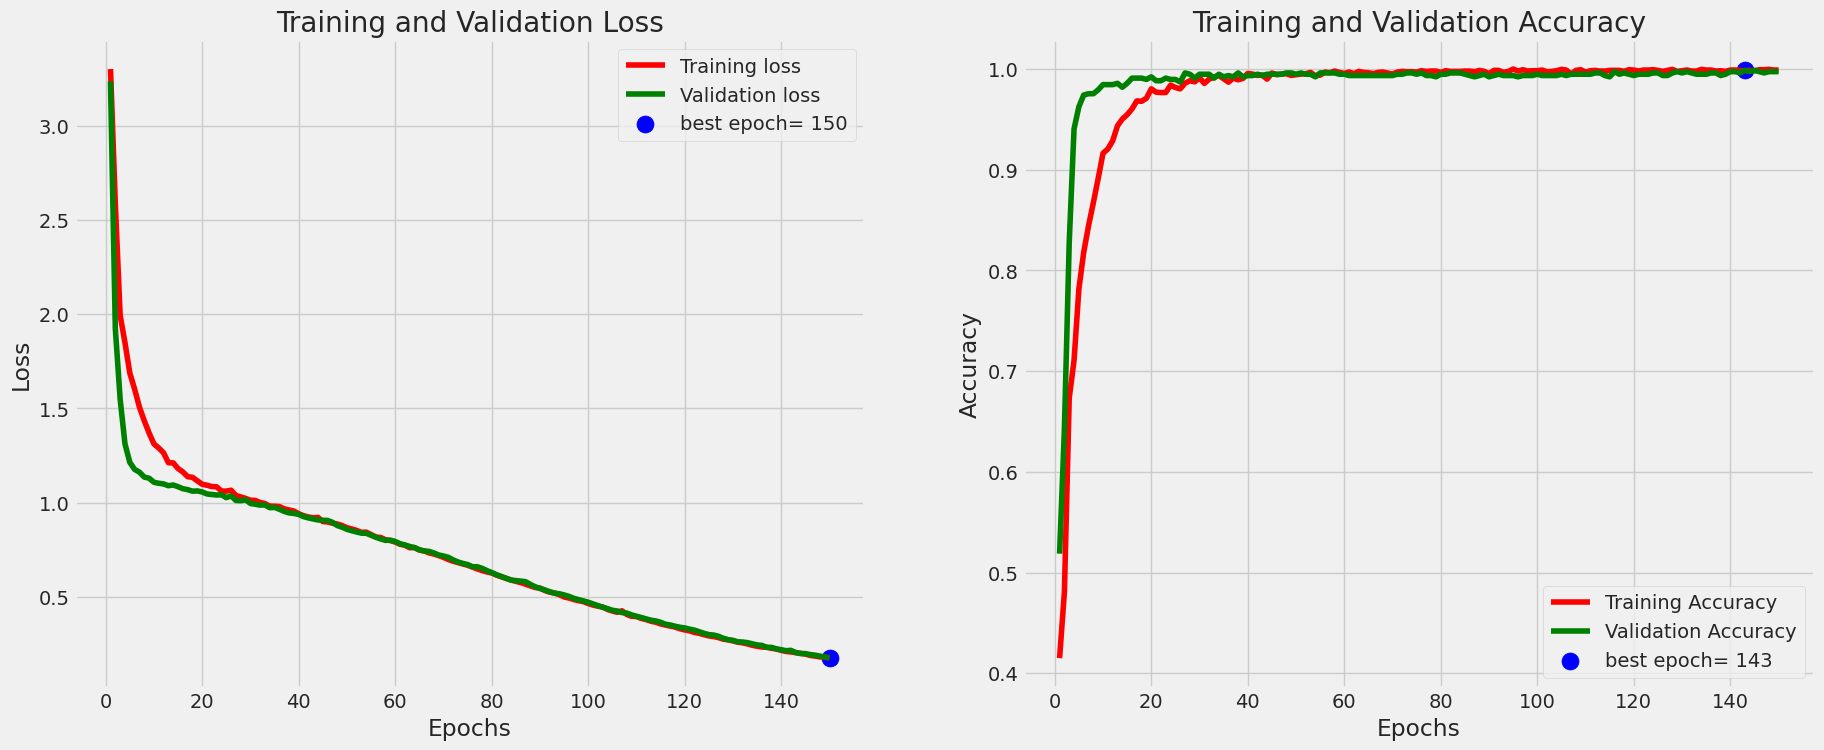

In [18]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    plt.show()

tr_plot(history,0)

<a id="result"></a>
# <center>Make Predictions on the test set</a>
### Define a function which takes in a test generator and an integer test_steps
### and generates predictions on the test set including a confusion matric
### and a classification report

7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 6s/step
file  /content/cauliflower_training/cali/Downy Mildew/downy_mildew_0995.jpg  was an error
file  /content/cauliflower_training/cali/Downy Mildew/downy_mildew_1173.jpg  was an error
there were 2 errors in 776 tests for an accuracy of  99.74


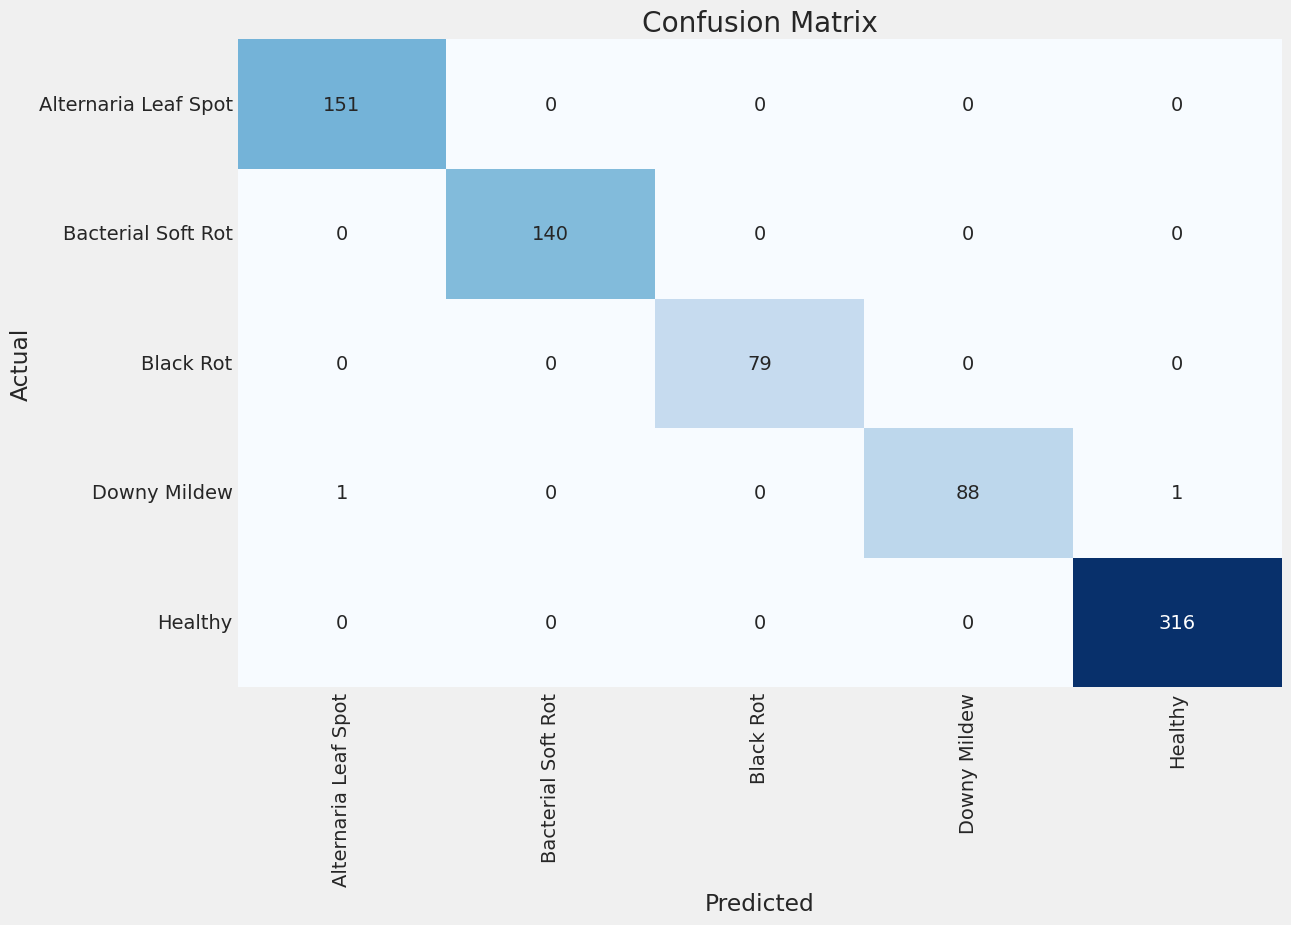

Classification Report:
----------------------
                       precision    recall  f1-score   support

Alternaria Leaf Spot     0.9934    1.0000    0.9967       151
  Bacterial Soft Rot     1.0000    1.0000    1.0000       140
           Black Rot     1.0000    1.0000    1.0000        79
        Downy Mildew     1.0000    0.9778    0.9888        90
             Healthy     0.9968    1.0000    0.9984       316

            accuracy                         0.9974       776
           macro avg     0.9981    0.9956    0.9968       776
        weighted avg     0.9974    0.9974    0.9974       776



In [19]:
def predictor_from_df(test_df, test_ds):
    y_true = test_df['labels'].map(class_to_idx).values
    filepaths = test_df['filepaths'].values
    class_names_local = class_names
    errors = 0
    preds = model.predict(test_ds, verbose=1)
    pred_indices = np.argmax(preds, axis=1)
    for i, (p, t) in enumerate(zip(pred_indices, y_true)):
        if p != t:
            errors += 1
            print('file ', filepaths[i], ' was an error')

    acc = (1 - errors/len(y_true)) * 100
    print(f'there were {errors} errors in {len(y_true)} tests for an accuracy of {acc:6.2f}')

    cm = confusion_matrix(y_true, pred_indices)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
    plt.xticks(np.arange(class_count)+.5, class_names_local, rotation=90)
    plt.yticks(np.arange(class_count)+.5, class_names_local, rotation=0)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    clr = classification_report(y_true, pred_indices, target_names=class_names_local, digits=4)
    print("Classification Report:\n----------------------\n", clr)
    return errors, len(y_true)

errors, tests = predictor_from_df(test_df, test_ds)

In [20]:
img_shape = (img_size[0], img_size[1], 3)

model_name = 'Xception'

print(f'Building {model_name} model...')

# Create base model
base_model = tf.keras.applications.Xception(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

base_model.trainable = True

# Build model with MODERATE regularization
x = base_model.output
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)

# Add intermediate layer for better feature learning
x = Dense(512, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(rate=.45, seed=123)(x)

x = Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(rate=.35, seed=123)(x)

# Output layer MUST be float32 for mixed precision
output = Dense(class_count, activation='softmax', dtype='float32', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model with lower initial learning rate
lr = 0.0005  # Reduced from 0.001 for more stable training
model.compile(
    Adamax(learning_rate=lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'\n✓ Model compiled with learning rate: {lr}')
print(f'  Total parameters: {model.count_params():,}')
model.summary()

Building Xception model...
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

✓ Model compiled with learning rate: 0.0005
  Total parameters: 22,051,373


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 22,051,373 (84.12 MB)

 Trainable params: 21,992,749 (83.90 MB)

 Non-trainable params: 58,624 (229.00 KB)

In [21]:
os.makedirs(quarantine_dir, exist_ok=True)
# Build class mapping
class_names = sorted(train_df['labels'].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
class_count = len(class_names)

# Helper to build tf.data datasets from dataframe
def df_to_dataset(df, training=False):
    paths = df['filepaths'].astype(str).values
    labels = df['labels'].map(class_to_idx).values.astype('int32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=1000, seed=123)
        ds = ds.map(lambda p, l: tf.py_function(func=_decode_and_preprocess_train, inp=[p, l], Tout=(tf.float32, tf.float32)), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda p, l: tf.py_function(func=_decode_and_preprocess_eval, inp=[p, l], Tout=(tf.float32, tf.float32)), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

# Functions used by tf.py_function must accept and return numpy-compatible types
def _decode_and_preprocess_train(path, label):
    path = path.numpy().decode('utf-8')
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.uint8).numpy()
    # Albumentations preprocessing returns float32 preprocessed image
    img_pp = albumentations_preprocess(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe

def _decode_and_preprocess_train(path, label):
    p = path.numpy().decode('utf-8')
    try:
        with Image.open(p) as im:
            im = im.convert('RGB')
            im = im.resize((img_size[1], img_size[0]))
            img = np.array(im, dtype=np.uint8)
    except Exception as e:
        # Move problematic file to quarantine to avoid repeated failures
        try:
            dest = os.path.join(quarantine_dir, os.path.basename(p))
            shutil.move(p, dest)
            print('Quarantined bad file:', p)
        except Exception:
            pass
        img = np.zeros((img_size[0], img_size[1], 3), dtype=np.uint8)
    img_pp = albumentations_preprocess(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe


def _decode_and_preprocess_eval(path, label):
    p = path.numpy().decode('utf-8')
    try:
        with Image.open(p) as im:
            im = im.convert('RGB')
            im = im.resize((img_size[1], img_size[0]))
            img = np.array(im, dtype=np.float32)
    except Exception:
        img = np.zeros((img_size[0], img_size[1], 3), dtype=np.float32)
    # Changed from efficientnet to xception preprocessing
    img_pp = tf.keras.applications.xception.preprocess_input(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe

In [22]:
def _py_train(path, label):
    img, lbl = tf.py_function(func=_decode_and_preprocess_train, inp=[path, label], Tout=(tf.float32, tf.float32))
    img.set_shape([img_size[0], img_size[1], 3])
    lbl.set_shape([class_count])
    return img, lbl


def _py_eval(path, label):
    img, lbl = tf.py_function(func=_decode_and_preprocess_eval, inp=[path, label], Tout=(tf.float32, tf.float32))
    img.set_shape([img_size[0], img_size[1], 3])
    lbl.set_shape([class_count])
    return img, lbl

# Rebuild TF datasets using the shape-aware wrappers defined earlier
print('Rebuilding tf.data datasets with robust PIL loaders...')
train_paths = train_df['filepaths'].astype(str).values
train_labels = train_df['labels'].map(class_to_idx).values.astype('int32')
valid_paths = valid_df['filepaths'].astype(str).values
valid_labels = valid_df['labels'].map(class_to_idx).values.astype('int32')
test_paths = test_df['filepaths'].astype(str).values
test_labels = test_df['labels'].map(class_to_idx).values.astype('int32')

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(buffer_size=1000, seed=123)
train_ds = train_ds.map(_py_train, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(AUTOTUNE)

valid_ds = tf.data.Dataset.from_tensor_slices((valid_paths, valid_labels))
valid_ds = valid_ds.map(_py_eval, num_parallel_calls=AUTOTUNE)
valid_ds = valid_ds.batch(batch_size).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(_py_eval, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(AUTOTUNE)

# Recompute steps
train_steps = int(np.ceil(len(train_df) / batch_size))
valid_steps = int(np.ceil(len(valid_df) / batch_size))
test_steps = int(np.ceil(len(test_df) / batch_size))

print(f'  Train steps (batches): {train_steps}')
print(f'  Valid steps (batches): {valid_steps}')
print(f'  Test steps (batches): {test_steps}')

Rebuilding tf.data datasets with robust PIL loaders...
  Train steps (batches): 24
  Valid steps (batches): 7
  Test steps (batches): 7


In [23]:
epochs = 150  # Increased for better convergence

# Save best model to Google Drive
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_cauliflower_model_xception.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by half
    patience=4,  # Wait 3 epochs before reducing
    min_lr=1e-7,
    verbose=1,
    mode='min'
)

# Stop early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,  # Increased patience for better training
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

callbacks = [checkpoint, reduce_lr, early_stop]
print('✓ Callbacks configured:')

✓ Callbacks configured:


In [24]:
print('STARTING TRAINING')
print('=' * 80)
print(f'Model: {model_name}')
print(f'Epochs: {epochs}')
print(f'Batch size: {batch_size}')
print(f'Steps per epoch: {train_steps}')
print(f'Validation steps: {valid_steps}')
print('=' * 80)

history = model.fit(
    x=train_ds,
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_ds,
    steps_per_epoch=train_steps,
    validation_steps=valid_steps,
    shuffle=False,
    initial_epoch=0
)

print('\n✓ Training completed!')

STARTING TRAINING
Model: Xception
Epochs: 150
Batch size: 128
Steps per epoch: 24
Validation steps: 7
Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5498 - loss: 2.8876   
Epoch 1: val_loss improved from inf to 3.15610, saving model to /content/drive/MyDrive/best_cauliflower_model_xception.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 211s 6s/step - accuracy: 0.5472 - loss: 2.9018 - val_accuracy: 0.2452 - val_loss: 3.1561 - learning_rate: 5.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.3650 - loss: 3.1522
Epoch 2: val_loss did not improve from 3.15610
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 779ms/step - accuracy: 0.3699 - loss: 3.1326 - val_accuracy: 0.0955 - val_loss: 3.4687 - learning_rate: 5.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.6861 - loss: 2.0165
Epoch 3: val_loss did not improve from 3.15610
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 767ms/step - accuracy: 0.6877 - loss: 2.0128 - val_accuracy: 0.1006 - val_loss: 3.8252 - learning_rate: 5.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.7186 - loss: 1.9096
Epoch 4: val_loss did not improve from 3.15610
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 768ms/step - accuracy: 0.7205 - loss: 1.9041 - val_accuracy: 0.1006 - val_loss: 3.8826 - learning_rate: 5.0000e-04
Epoch 5/150
24/2

In [25]:
print('\n' + '=' * 80)
print('POST-TRAINING ANALYSIS')
print('=' * 80)

# Check final metrics
final_train_loss = history.history['loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f'\nFinal Training   - Loss: {final_train_loss:.4f}, Accuracy: {final_train_acc:.4f}')
print(f'Final Validation - Loss: {final_val_loss:.4f}, Accuracy: {final_val_acc:.4f}')

# Find best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = np.min(history.history['val_loss'])
best_val_acc = history.history['val_accuracy'][best_epoch - 1]

print(f'\nBest Epoch: {best_epoch}')
print(f'  Validation Loss: {best_val_loss:.4f}')
print(f'  Validation Accuracy: {best_val_acc:.4f}')

# Quick sanity check on a few predictions
print('\n🔍 Quick Prediction Check (first 10 validation samples):')
val_batch, val_labels_batch = next(iter(valid_ds))
val_predictions = model.predict(val_batch[:10])
val_pred_classes = np.argmax(val_predictions, axis=1)
val_class_names = [classes[i] for i in val_pred_classes]
print('Predicted classes:', val_class_names)

unique_preds = np.unique(val_pred_classes)
if len(unique_preds) > 1:
    print('✅ GOOD: Model is predicting MULTIPLE classes (not just Healthy)!')
else:
    print('⚠️ WARNING: Model still predicting only one class. Check training logs.')

print('=' * 80)


POST-TRAINING ANALYSIS

Final Training   - Loss: 1.3069, Accuracy: 0.9413
Final Validation - Loss: 5.4234, Accuracy: 0.1006

Best Epoch: 1
  Validation Loss: 3.1561
  Validation Accuracy: 0.2452

🔍 Quick Prediction Check (first 10 validation samples):
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Predicted classes: ['Healthy', 'Downy Mildew', 'Black Rot', 'Black Rot', 'Healthy', 'Downy Mildew', 'Downy Mildew', 'Black Rot', 'Black Rot', 'Black Rot']
✅ GOOD: Model is predicting MULTIPLE classes (not just Healthy)!


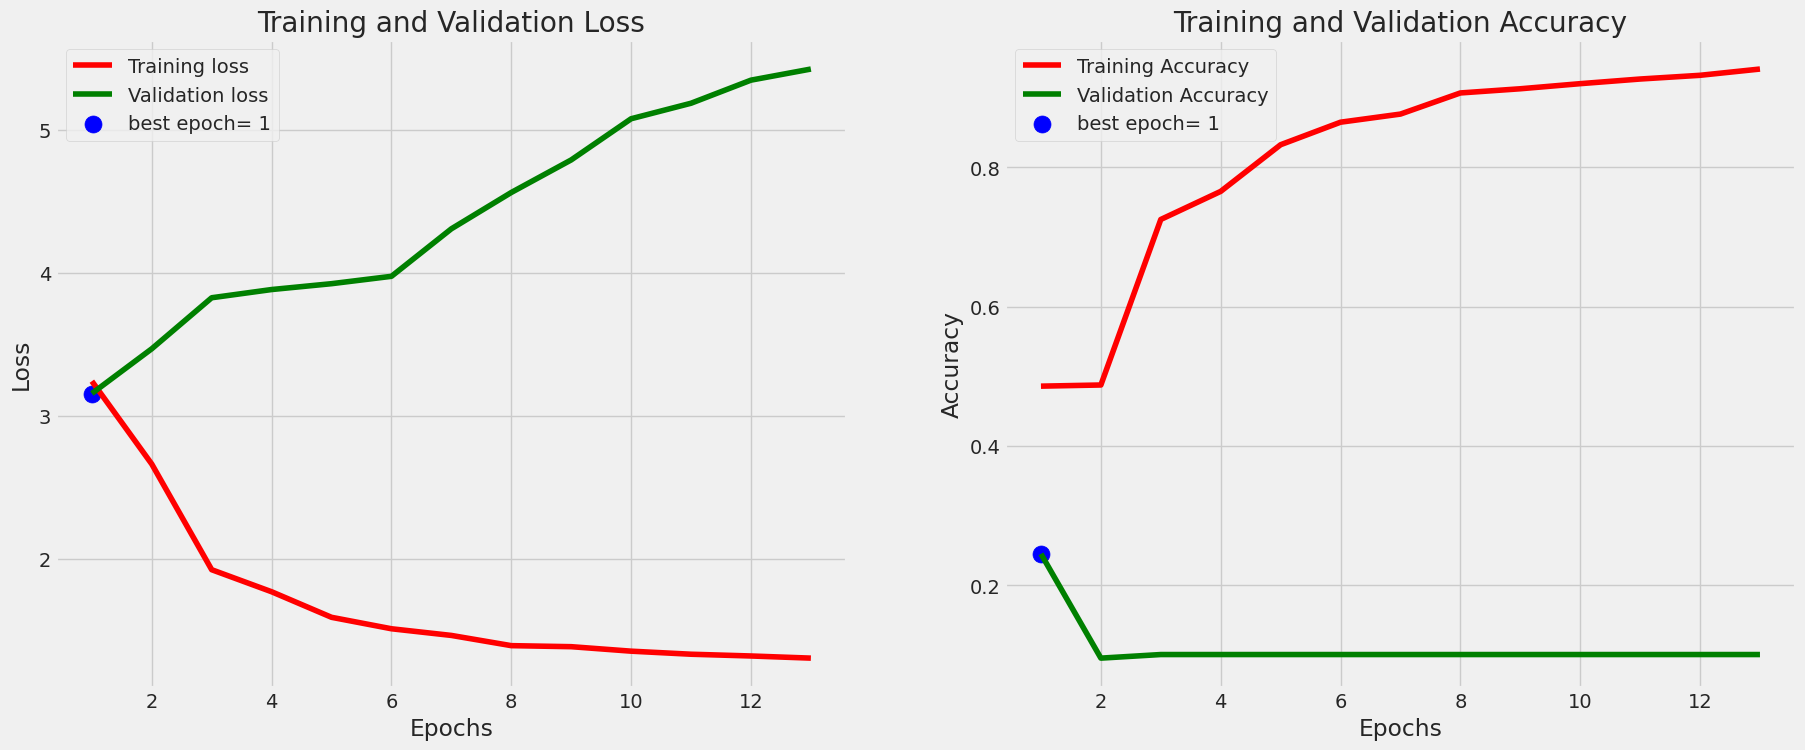

In [26]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    plt.show()

tr_plot(history,0)

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_0424.jpg  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_1447.jpg  was an error
file  /content/cauliflower_training/cali/Healthy/healthy_2144.jpg  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_1074.jpg  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_1363.jpg  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_0620.jpg  was an error
file  /content/cauliflower_training/cali/Bacterial Soft Rot/bacterial_soft_rot_1157.jpg  was an error
file  /content/cauliflower_training/cali/Healthy/healthy_0769.jpeg  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_0076.jpg  was an error
file  /content/cauliflower_training/cali/Healthy/healthy_1104.jp

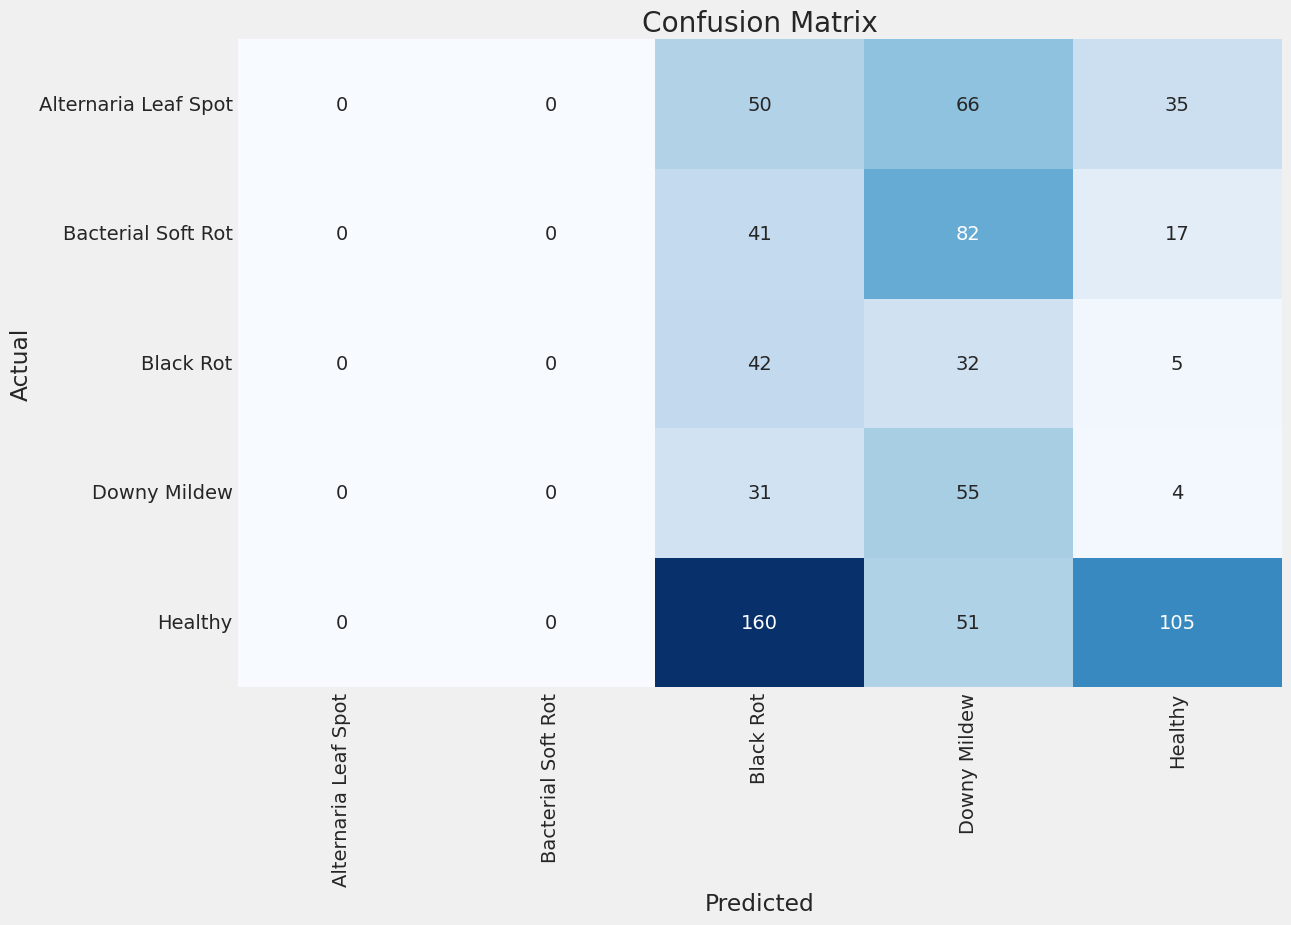

Classification Report:
----------------------
                       precision    recall  f1-score   support

Alternaria Leaf Spot     0.0000    0.0000    0.0000       151
  Bacterial Soft Rot     0.0000    0.0000    0.0000       140
           Black Rot     0.1296    0.5316    0.2084        79
        Downy Mildew     0.1923    0.6111    0.2926        90
             Healthy     0.6325    0.3323    0.4357       316

            accuracy                         0.2603       776
           macro avg     0.1909    0.2950    0.1873       776
        weighted avg     0.2931    0.2603    0.2326       776



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
def predictor_from_df(test_df, test_ds):
    y_true = test_df['labels'].map(class_to_idx).values
    filepaths = test_df['filepaths'].values
    class_names_local = class_names
    errors = 0
    preds = model.predict(test_ds, verbose=1)
    pred_indices = np.argmax(preds, axis=1)
    for i, (p, t) in enumerate(zip(pred_indices, y_true)):
        if p != t:
            errors += 1
            print('file ', filepaths[i], ' was an error')

    acc = (1 - errors/len(y_true)) * 100
    print(f'there were {errors} errors in {len(y_true)} tests for an accuracy of {acc:6.2f}')

    cm = confusion_matrix(y_true, pred_indices)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
    plt.xticks(np.arange(class_count)+.5, class_names_local, rotation=90)
    plt.yticks(np.arange(class_count)+.5, class_names_local, rotation=0)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    clr = classification_report(y_true, pred_indices, target_names=class_names_local, digits=4)
    print("Classification Report:\n----------------------\n", clr)
    return errors, len(y_true)

errors, tests = predictor_from_df(test_df, test_ds)

In [28]:
img_shape = (img_size[0], img_size[1], 3)

model_name = 'DenseNet121'

print(f'Building {model_name} model...')

# Create base model
base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

base_model.trainable = True

# Build model with MODERATE regularization
x = base_model.output
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)

# Add intermediate layer for better feature learning
x = Dense(512, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(rate=.45, seed=123)(x)

x = Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(rate=.35, seed=123)(x)

# Output layer MUST be float32 for mixed precision
output = Dense(class_count, activation='softmax', dtype='float32', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model with lower initial learning rate
lr = 0.0005  # Reduced from 0.001 for more stable training
model.compile(
    Adamax(learning_rate=lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'\n✓ Model compiled with learning rate: {lr}')
print(f'  Total parameters: {model.count_params():,}')
model.summary()

Building DenseNet121 model...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

✓ Model compiled with learning rate: 0.0005
  Total parameters: 7,699,013


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 306, 306,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 150, 150,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 150, 150,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 150, 150,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 152, 152,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 75, 75,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 75, 75,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 75, 75,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 75, 75,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 75, 75,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 75, 75,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 75, 75,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 75, 75,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 75, 75,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 75, 75,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 75, 75,    │     12,288 │ conv2_block2_0_r

 Total params: 7,699,013 (29.37 MB)

 Trainable params: 7,613,317 (29.04 MB)

 Non-trainable params: 85,696 (334.75 KB)

In [29]:
os.makedirs(quarantine_dir, exist_ok=True)
# Build class mapping
class_names = sorted(train_df['labels'].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
class_count = len(class_names)

# Helper to build tf.data datasets from dataframe
def df_to_dataset(df, training=False):
    paths = df['filepaths'].astype(str).values
    labels = df['labels'].map(class_to_idx).values.astype('int32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=1000, seed=123)
        ds = ds.map(lambda p, l: tf.py_function(func=_decode_and_preprocess_train, inp=[p, l], Tout=(tf.float32, tf.float32)), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda p, l: tf.py_function(func=_decode_and_preprocess_eval, inp=[p, l], Tout=(tf.float32, tf.float32)), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

# Functions used by tf.py_function must accept and return numpy-compatible types
def _decode_and_preprocess_train(path, label):
    path = path.numpy().decode('utf-8')
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.uint8).numpy()
    # Albumentations preprocessing returns float32 preprocessed image
    img_pp = albumentations_preprocess(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe

def _decode_and_preprocess_train(path, label):
    p = path.numpy().decode('utf-8')
    try:
        with Image.open(p) as im:
            im = im.convert('RGB')
            im = im.resize((img_size[1], img_size[0]))
            img = np.array(im, dtype=np.uint8)
    except Exception as e:
        try:
            dest = os.path.join(quarantine_dir, os.path.basename(p))
            shutil.move(p, dest)
            print('Quarantined bad file:', p)
        except Exception:
            pass
        img = np.zeros((img_size[0], img_size[1], 3), dtype=np.uint8)
    img_pp = albumentations_preprocess(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe

def _decode_and_preprocess_eval(path, label):
    p = path.numpy().decode('utf-8')
    try:
        with Image.open(p) as im:
            im = im.convert('RGB')
            im = im.resize((img_size[1], img_size[0]))
            img = np.array(im, dtype=np.float32)
    except Exception:
        img = np.zeros((img_size[0], img_size[1], 3), dtype=np.float32)
    # Changed to DenseNet preprocessing
    img_pp = tf.keras.applications.densenet.preprocess_input(img)
    label_ohe = tf.one_hot(int(label.numpy()), depth=class_count).numpy()
    return img_pp, label_ohe

In [30]:
def _py_train(path, label):
    img, lbl = tf.py_function(func=_decode_and_preprocess_train, inp=[path, label], Tout=(tf.float32, tf.float32))
    img.set_shape([img_size[0], img_size[1], 3])
    lbl.set_shape([class_count])
    return img, lbl


def _py_eval(path, label):
    img, lbl = tf.py_function(func=_decode_and_preprocess_eval, inp=[path, label], Tout=(tf.float32, tf.float32))
    img.set_shape([img_size[0], img_size[1], 3])
    lbl.set_shape([class_count])
    return img, lbl

# Rebuild TF datasets using the shape-aware wrappers defined earlier
print('Rebuilding tf.data datasets with robust PIL loaders...')
train_paths = train_df['filepaths'].astype(str).values
train_labels = train_df['labels'].map(class_to_idx).values.astype('int32')
valid_paths = valid_df['filepaths'].astype(str).values
valid_labels = valid_df['labels'].map(class_to_idx).values.astype('int32')
test_paths = test_df['filepaths'].astype(str).values
test_labels = test_df['labels'].map(class_to_idx).values.astype('int32')

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(buffer_size=1000, seed=123)
train_ds = train_ds.map(_py_train, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(AUTOTUNE)

valid_ds = tf.data.Dataset.from_tensor_slices((valid_paths, valid_labels))
valid_ds = valid_ds.map(_py_eval, num_parallel_calls=AUTOTUNE)
valid_ds = valid_ds.batch(batch_size).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(_py_eval, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(AUTOTUNE)

# Recompute steps
train_steps = int(np.ceil(len(train_df) / batch_size))
valid_steps = int(np.ceil(len(valid_df) / batch_size))
test_steps = int(np.ceil(len(test_df) / batch_size))

print(f'  Train steps (batches): {train_steps}')
print(f'  Valid steps (batches): {valid_steps}')
print(f'  Test steps (batches): {test_steps}')

Rebuilding tf.data datasets with robust PIL loaders...
  Train steps (batches): 24
  Valid steps (batches): 7
  Test steps (batches): 7


In [31]:
epochs = 150

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_cauliflower_model_densenet121.h5',  # Updated filename
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

callbacks = [checkpoint, reduce_lr, early_stop]
print('✓ Callbacks configured')

✓ Callbacks configured


In [32]:
print('STARTING TRAINING')
print('=' * 80)
print(f'Model: {model_name}')
print(f'Epochs: {epochs}')
print(f'Batch size: {batch_size}')
print(f'Learning rate: {lr}')
print(f'Steps per epoch: {train_steps}')
print(f'Validation steps: {valid_steps}')
print('=' * 80)

history = model.fit(
    x=train_ds,
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_ds,
    steps_per_epoch=train_steps,
    validation_steps=valid_steps,
    shuffle=False,
    initial_epoch=0
)

print(f'\n✓ Training completed for {model_name}!')

STARTING TRAINING
Model: DenseNet121
Epochs: 150
Batch size: 128
Learning rate: 0.0005
Steps per epoch: 24
Validation steps: 7
Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4940 - loss: 2.6353   
Epoch 1: val_loss improved from inf to 5.17903, saving model to /content/drive/MyDrive/best_cauliflower_model_densenet121.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 349s 7s/step - accuracy: 0.4923 - loss: 2.6446 - val_accuracy: 0.1161 - val_loss: 5.1790 - learning_rate: 5.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.4755 - loss: 2.2870
Epoch 2: val_loss improved from 5.17903 to 3.14601, saving model to /content/drive/MyDrive/best_cauliflower_model_densenet121.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 871ms/step - accuracy: 0.4788 - loss: 2.2792 - val_accuracy: 0.1006 - val_loss: 3.1460 - learning_rate: 5.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.6514 - loss: 1.8478
Epoch 3: val_loss improved from 3.14601 to 2.90757, saving model to /content/drive/MyDrive/best_cauliflower_model_densenet121.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 858ms/step - accuracy: 0.6531 - loss: 1.8442 - val_accuracy: 0.1006 - val_loss: 2.9076 - learning_rate: 5.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.7240 - loss: 1.6561
Epoch 4: val_loss improved from 2.90757 to 2.80968, saving model to /content/drive/MyDrive/best_cauliflower_model_densenet121.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 859ms/step - accuracy: 0.7257 - loss: 1.6523 - val_accuracy: 0.0968 - val_loss: 2.8097 - learning_rate: 5.0000e-04
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.7937 - loss: 1.5002
Epoch 5: val_loss improved from 2.80968 to 2.76453, saving model to /content/drive/MyDrive/best_cauliflower_model_densenet121.h5


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 865ms/step - accuracy: 0.7947 - loss: 1.4975 - val_accuracy: 0.4090 - val_loss: 2.7645 - learning_rate: 5.0000e-04
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.7964 - loss: 1.4584
Epoch 6: val_loss did not improve from 2.76453
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 724ms/step - accuracy: 0.7978 - loss: 1.4550 - val_accuracy: 0.3665 - val_loss: 2.7975 - learning_rate: 5.0000e-04
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.8428 - loss: 1.3386
Epoch 7: val_loss did not improve from 2.76453
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 718ms/step - accuracy: 0.8440 - loss: 1.3359 - val_accuracy: 0.4077 - val_loss: 2.7793 - learning_rate: 5.0000e-04
Epoch 8/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.8775 - loss: 1.2507
Epoch 8: val_loss did not improve from 2.76453
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 725ms/step - accuracy: 0.8781 - loss: 1.2494 - val_accuracy: 0.2232 - val_loss: 2.8168 - learning_rate: 5.0000e-04
Epoch 9/150
24

In [33]:
print('\n' + '=' * 80)
print('POST-TRAINING ANALYSIS')
print('=' * 80)

final_train_loss = history.history['loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f'\nFinal Training   - Loss: {final_train_loss:.4f}, Accuracy: {final_train_acc:.4f}')
print(f'Final Validation - Loss: {final_val_loss:.4f}, Accuracy: {final_val_acc:.4f}')

best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = np.min(history.history['val_loss'])
best_val_acc = history.history['val_accuracy'][best_epoch - 1]

print(f'\nBest Epoch: {best_epoch}')
print(f'  Validation Loss: {best_val_loss:.4f}')
print(f'  Validation Accuracy: {best_val_acc:.4f}')

print('\n🔍 Quick Prediction Check (first 10 validation samples):')
val_batch, val_labels_batch = next(iter(valid_ds))
val_predictions = model.predict(val_batch[:10])
val_pred_classes = np.argmax(val_predictions, axis=1)
val_class_names = [classes[i] for i in val_pred_classes]
print('Predicted classes:', val_class_names)

unique_preds = np.unique(val_pred_classes)
if len(unique_preds) > 1:
    print('✅ GOOD: Model is predicting MULTIPLE classes (not just Healthy)!')
else:
    print('⚠️ WARNING: Model still predicting only one class. Check training logs.')

print('=' * 80)


POST-TRAINING ANALYSIS

Final Training   - Loss: 0.9943, Accuracy: 0.9627
Final Validation - Loss: 3.1198, Accuracy: 0.1806

Best Epoch: 5
  Validation Loss: 2.7645
  Validation Accuracy: 0.4090

🔍 Quick Prediction Check (first 10 validation samples):
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
Predicted classes: ['Healthy', 'Healthy', 'Healthy', 'Healthy', 'Healthy', 'Healthy', 'Healthy', 'Healthy', 'Healthy', 'Healthy']
⚠️ WARNING: Model still predicting only one class. Check training logs.


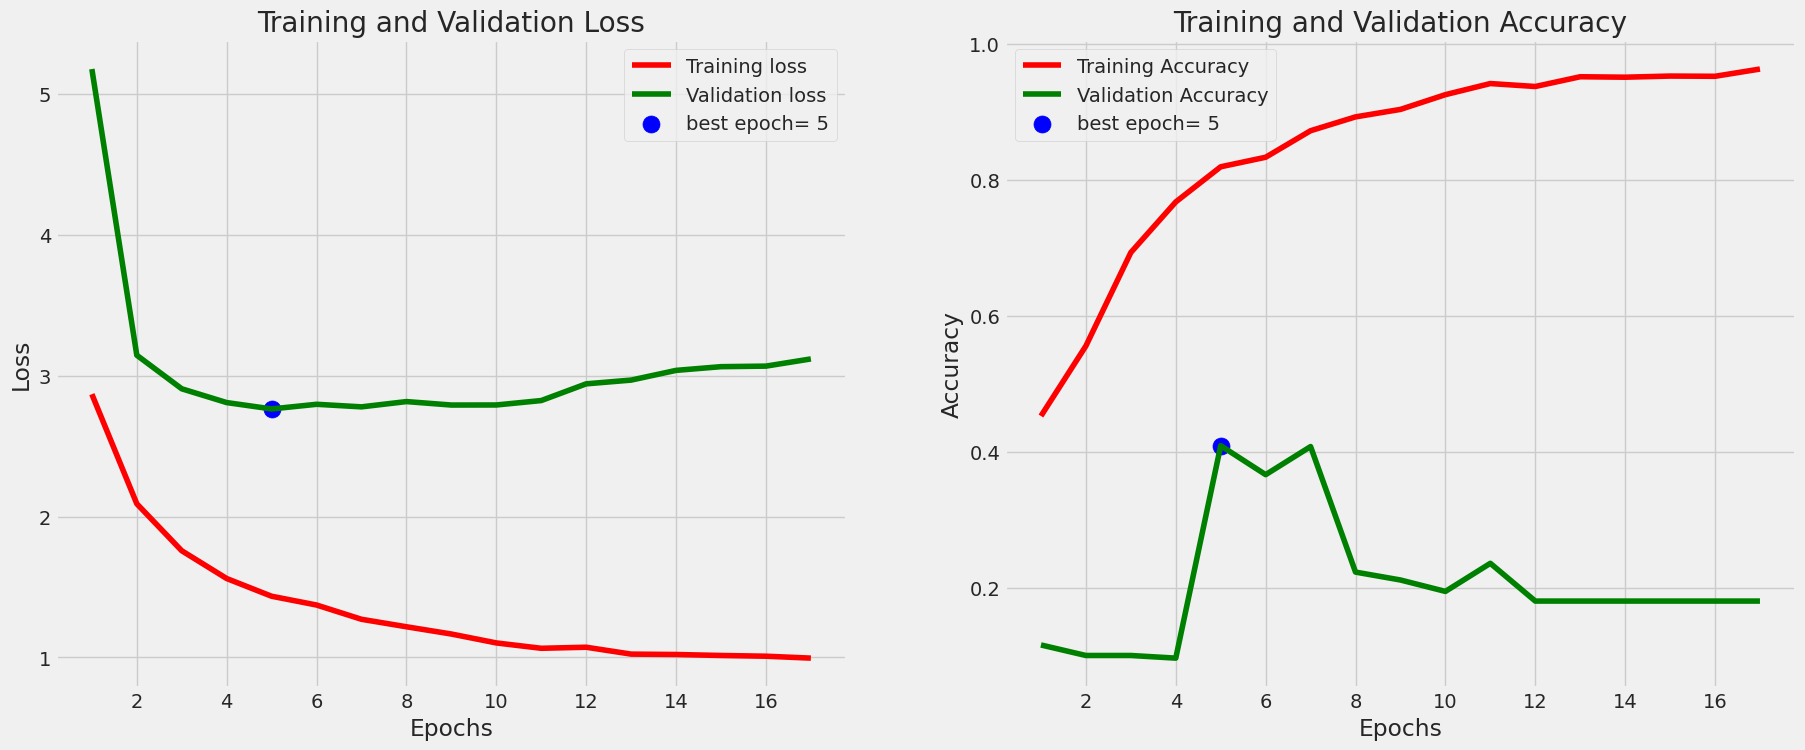

In [34]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    plt.show()

tr_plot(history,0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_0424.jpg  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_1447.jpg  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_1074.jpg  was an error
file  /content/cauliflower_training/cali/Black Rot/black_rot_663.png  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_1363.jpg  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_0620.jpg  was an error
file  /content/cauliflower_training/cali/Downy Mildew/downy_mildew_0128.png  was an error
file  /content/cauliflower_training/cali/Bacterial Soft Rot/bacterial_soft_rot_1157.jpg  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_0076.jpg  was an error
file  /content/cauliflower_training/cali/Bacterial S

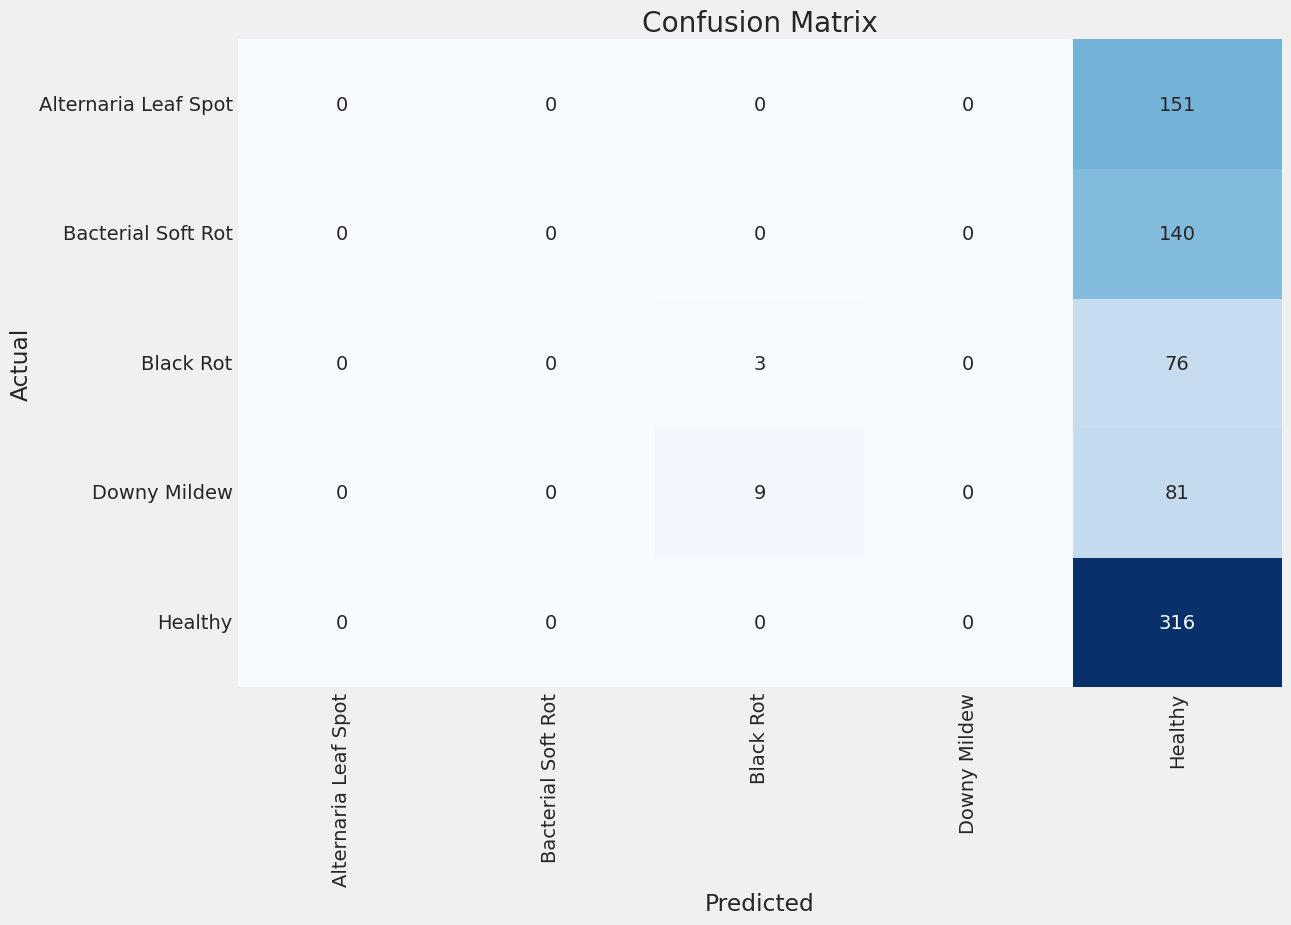

Classification Report:
----------------------
                       precision    recall  f1-score   support

Alternaria Leaf Spot     0.0000    0.0000    0.0000       151
  Bacterial Soft Rot     0.0000    0.0000    0.0000       140
           Black Rot     0.2500    0.0380    0.0659        79
        Downy Mildew     0.0000    0.0000    0.0000        90
             Healthy     0.4136    1.0000    0.5852       316

            accuracy                         0.4111       776
           macro avg     0.1327    0.2076    0.1302       776
        weighted avg     0.1939    0.4111    0.2450       776



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
def predictor_from_df(test_df, test_ds):
    y_true = test_df['labels'].map(class_to_idx).values
    filepaths = test_df['filepaths'].values
    class_names_local = class_names
    errors = 0
    preds = model.predict(test_ds, verbose=1)
    pred_indices = np.argmax(preds, axis=1)
    for i, (p, t) in enumerate(zip(pred_indices, y_true)):
        if p != t:
            errors += 1
            print('file ', filepaths[i], ' was an error')

    acc = (1 - errors/len(y_true)) * 100
    print(f'there were {errors} errors in {len(y_true)} tests for an accuracy of {acc:6.2f}')

    cm = confusion_matrix(y_true, pred_indices)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
    plt.xticks(np.arange(class_count)+.5, class_names_local, rotation=90)
    plt.yticks(np.arange(class_count)+.5, class_names_local, rotation=0)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    clr = classification_report(y_true, pred_indices, target_names=class_names_local, digits=4)
    print("Classification Report:\n----------------------\n", clr)
    return errors, len(y_true)

errors, tests = predictor_from_df(test_df, test_ds)

<a id="save"></a>
# <center>Save the model

In [36]:
subject='nuts'
acc=str(( 1-errors/tests) * 100)
index=acc.rfind('.')
acc=acc[:index + 3]
save_id= subject + '_' + str(acc) + '.h5'
model_save_loc=os.path.join(working_dir, save_id)
model.save(model_save_loc)
print ('model was saved as ' , model_save_loc )


model was saved as  ./nuts_41.10.h5
